In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
import sys

sys.executable
sys.version

'3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]'

In [3]:
df = pd.read_csv('../data/raw/instagram_usage_lifestyle.csv')
type (df)
pd.core.frame.DataFrame

pandas.core.frame.DataFrame

In [4]:
df_work = df.copy()

# Drop columns that are not needed at this stage
drop_cols = [
    "user_id",
    "app_name",
    "income_level",
    "age",
    "gender",
    "country",
    "urban_rural",
    "employment_status",
    "education_level",
    "relationship_status",
    "has_children",
    "diet_quality",
    "smoking",
    "alcohol_frequency",
    "last_login_date",
]

df_work.drop(columns=drop_cols, inplace=True, errors="ignore")

# Check
df_work.shape


(1547896, 43)

In [5]:
df_work = df_work.sample(
    n=10000,
    random_state=42
).reset_index(drop=True)


In [6]:
df_work["creator_post_ratio"] = (
    df_work["posts_created_per_week"] / (df_work["sessions_per_day"] + 1)
)

df_work["broadcast_ratio"] = (
    df_work["posts_created_per_week"] /
    (df_work["stories_viewed_per_day"] + df_work["reels_watched_per_day"] + 1)
)

df_work["audience_ratio"] = (
    df_work["followers_count"] / (df_work["following_count"] + 1)
)

df_work.shape

(10000, 46)

In [11]:
Activity_cols = [
    "user_engagement_score",
    "sessions_per_day",
    "daily_active_minutes_instagram",
    "average_session_length_minutes",
    "likes_given_per_day",
    "comments_written_per_day",
    "stories_viewed_per_day",
    "reels_watched_per_day",
    "time_on_feed_per_day",
    "time_on_reels_per_day",
]

Creator_cols = [
    "creator_post_ratio",
    "broadcast_ratio",
    "audience_ratio",
]

XY = df_work[Activity_cols + Creator_cols]
XY.shape


(10000, 13)

In [13]:
scaler = StandardScaler()
XY_scaled = scaler.fit_transform(XY)

pca = PCA(n_components=2, random_state=42)
XY_pca = pca.fit_transform(XY_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index = Activity_cols + Creator_cols,
    columns=["PCA1", "PCA2"]
)

loadings.sort_values("PCA1", ascending=False)


,PCA1,PCA2
daily_active_minutes_instagram,0.356660,0.091904
likes_given_per_day,0.350930,0.093270
time_on_feed_per_day,0.349829,0.092380
stories_viewed_per_day,0.347995,0.060745
comments_written_per_day,0.340914,0.092680
time_on_reels_per_day,0.338624,0.092663
reels_watched_per_day,0.318414,0.167258
sessions_per_day,0.280197,0.052674
average_session_length_minutes,0.069555,-0.073124
audience_ratio,-0.001342,0.018419


In [15]:
kmeans = KMeans(
    n_clusters=4,
    n_init=20,
    random_state=42
)

labels = kmeans.fit_predict(XY_pca)

sil = silhouette_score(XY_pca, labels)
sil

0.4093573830292202

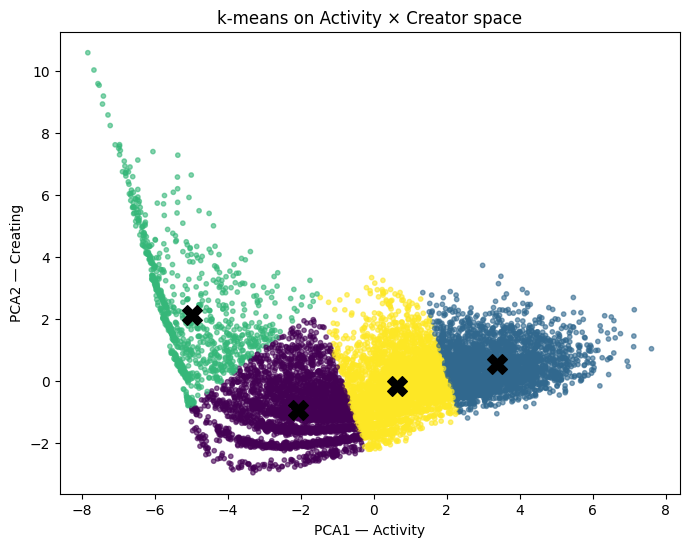

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(
    XY_pca[:, 0],
    XY_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X"
)

plt.xlabel("PCA1 — Activity")
plt.ylabel("PCA2 — Creating")
plt.title("k-means on Activity × Creator space")
plt.show()


In [ ]:
df_seg = df_work.copy()
df_seg["cluster"] = labels

df_seg.groupby("cluster")[[
    "posts_created_per_week",
    "creator_post_ratio",
    "broadcast_ratio",
    "sessions_per_day",
    "daily_active_minutes_instagram"
]].mean()

,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,3.376192,0.624700,0.018051,5.177573,96.071358
1,8.835832,0.531618,0.021477,18.564783,328.750096
2,5.073016,2.081875,0.044855,1.453968,21.122751
3,6.528274,0.606514,0.020755,11.218576,208.715500


In [21]:
df_income = df.loc[df_work.index, ["income_level"]].reset_index(drop=True)
df_seg = df_seg.reset_index(drop=True)

df_seg["income_level"] = df_income["income_level"]

df_seg[["cluster", "income_level"]].head()

,cluster,income_level
0,3,High
1,3,Middle
2,3,Middle
3,2,Middle
4,3,Upper-middle


In [24]:
income_counts = (
    df_seg
    .groupby(["cluster", "income_level"])
    .size()
    .reset_index(name="count")
)
income_share = (
    income_counts
    .assign(
        share=lambda x: x["count"] /
        x.groupby("cluster")["count"].transform("sum")
    )
)

income_share


,cluster,income_level,count,share
0,0,High,284,0.093390
1,0,Low,627,0.206182
2,0,Lower-middle,736,0.242026
3,0,Middle,911,0.299573
4,0,Upper-middle,483,0.158829
5,1,High,276,0.106113
6,1,Low,518,0.199154
7,1,Lower-middle,669,0.257209
8,1,Middle,776,0.298347
9,1,Upper-middle,362,0.139177


In [ ]:
income_pivot = (
    income_share
    .pivot(index="cluster", columns="income_level", values="share")
    .fillna(0)
)

income_pivot

income_level,High,Low,Lower-middle,Middle,Upper-middle
cluster,,,,,
0,0.093390,0.206182,0.242026,0.299573,0.158829
1,0.106113,0.199154,0.257209,0.298347,0.139177
2,0.093122,0.215873,0.228571,0.295238,0.167196
3,0.089657,0.196894,0.256666,0.303252,0.153531


In [26]:
df_seg.groupby("cluster")[[
    "posts_created_per_week",
    "creator_post_ratio",
    "broadcast_ratio",
    "sessions_per_day",
    "daily_active_minutes_instagram"
]].mean()

,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,3.376192,0.624700,0.018051,5.177573,96.071358
1,8.835832,0.531618,0.021477,18.564783,328.750096
2,5.073016,2.081875,0.044855,1.453968,21.122751
3,6.528274,0.606514,0.020755,11.218576,208.715500


In [ ]:
df_work["privacy_setting_level"].value_counts()

privacy_setting_level
Private         3406
Friends only    3330
Public          3264
Name: count, dtype: int64

In [ ]:
df_work["two_factor_auth_enabled"].value_counts() 

two_factor_auth_enabled
Yes    6553
No     3447
Name: count, dtype: int64

In [ ]:
df_work["biometric_login_used"].value_counts()

biometric_login_used
No     5952
Yes    4048
Name: count, dtype: int64

In [ ]:
df_work["linked_accounts_count"].value_counts()

linked_accounts_count
1    2686
2    2669
3    1774
0    1425
4     909
5     537
Name: count, dtype: int64

In [ ]:
#Try to create security axis
privacy_map = {
    "Public": 0,
    "Friends only": 1,
    "Private": 2
}
df_work["privacy_level_encoded"] = (
    df_work["privacy_setting_level"]
    .map(privacy_map)
)

binary_map = {"Yes": 1, "No": 0}
df_work["two_factor_enabled"] = (
    df_work["two_factor_auth_enabled"]
    .map(binary_map)
)
df_work["biometric_login"] = (
    df_work["biometric_login_used"]
    .map(binary_map)
)

df_work["linked_accounts_count"] = df_work["linked_accounts_count"]

Security_cols = [
    "privacy_level_encoded",
    "two_factor_enabled",
    "biometric_login",
    "linked_accounts_count",
]

XYZ = df_work[Activity_cols + Creator_cols + Security_cols]
XYZ.shape

(10000, 17)

In [32]:
scaler = StandardScaler()
XYZ_scaled = scaler.fit_transform(XYZ)

pca_xyz = PCA(n_components=3, random_state=42)
XYZ_pca = pca_xyz.fit_transform(XYZ_scaled)

loadings_xyz = pd.DataFrame(
    pca_xyz.components_.T,
    index=Activity_cols + Creator_cols + Security_cols,
    columns=["PCA1", "PCA2", "PCA3"]
)

loadings_xyz


,PCA1,PCA2,PCA3
user_engagement_score,-0.226080,0.326199,-0.282112
sessions_per_day,0.280189,0.053046,-0.446387
daily_active_minutes_instagram,0.356643,0.091798,0.011848
average_session_length_minutes,0.069533,-0.073690,0.805139
likes_given_per_day,0.350910,0.093118,0.013378
comments_written_per_day,0.340896,0.092596,0.014450
stories_viewed_per_day,0.347974,0.060659,0.029343
reels_watched_per_day,0.318390,0.167142,0.055997
time_on_feed_per_day,0.349810,0.092214,0.012614
time_on_reels_per_day,0.338606,0.092642,0.008322


The security parameters are meaningless

In [34]:
scores = {}

for k in range(3, 16):
    labels_k = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    ).fit_predict(XY_pca)
    
    scores[k] = silhouette_score(XY_pca, labels_k)

scores


{3: 0.4694683861269146,
 4: 0.4093573830292202,
 5: 0.3888542607389204,
 6: 0.3695812680276881,
 7: 0.38409020690610995,
 8: 0.357411713720448,
 9: 0.356106516012441,
 10: 0.34721879218615614,
 11: 0.3415080757902419,
 12: 0.3463805914433641,
 13: 0.3465929354916016,
 14: 0.33626147838825693,
 15: 0.3419133289182917}

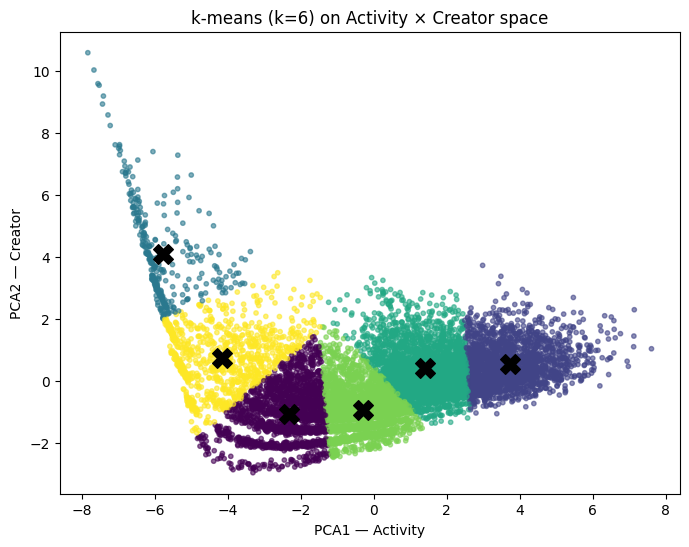

In [ ]:
kmeans6 = KMeans(
    n_clusters=6,
    n_init=20,
    random_state=42
)

labels6 = kmeans6.fit_predict(XY_pca)

plt.figure(figsize=(8, 6))
plt.scatter(
    XY_pca[:, 0],
    XY_pca[:, 1],
    c=labels6,
    s=10,
    alpha=0.6
)

centers = kmeans6.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X"
)

plt.xlabel("PCA1 — Activity")
plt.ylabel("PCA2 — Creator")
plt.title("k-means (k=6) on Activity × Creator space")
plt.show()

In [ ]:
df_seg6 = df_work.copy()
df_seg6["cluster"] = labels6

df_seg6.groupby("cluster")[[
    "posts_created_per_week",
    "creator_post_ratio",
    "broadcast_ratio",
    "sessions_per_day",
    "daily_active_minutes_instagram"
]].mean()

,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,3.133086,0.600068,0.017676,4.569989,84.334040
1,8.603735,0.483182,0.020436,19.748107,344.544170
2,6.410180,3.002196,0.061955,1.122754,12.610778
3,8.815685,0.734106,0.025536,12.913217,243.731290
4,3.761441,0.432513,0.014433,9.019068,164.771610
5,4.539374,1.470772,0.033716,2.003236,35.185545


In [52]:
df_seg6["income_level"] = df.loc[df_seg6.index, "income_level"]

income_share = (
    df_seg6
    .groupby("cluster")["income_level"]
    .value_counts(normalize=True)
    .unstack()
)

income_order = ["Low", "Lower-middle", "Middle", "Upper-middle", "High"]
income_share = income_share[income_order]
income_share


income_level,Low,Lower-middle,Middle,Upper-middle,High
cluster,,,,,
0,0.204136,0.247614,0.294274,0.162248,0.091729
1,0.199899,0.261989,0.299344,0.136295,0.102473
2,0.248503,0.221557,0.314371,0.122754,0.092814
3,0.193073,0.253981,0.298169,0.158041,0.096736
4,0.210169,0.244068,0.307203,0.147881,0.090678
5,0.189860,0.240561,0.295577,0.176915,0.097087


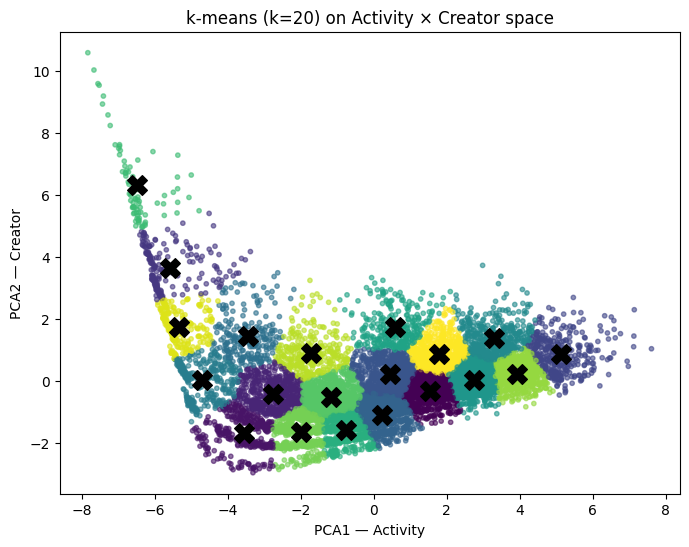

In [45]:
kmeans20 = KMeans(
    n_clusters=20,
    n_init=20,
    random_state=42
)

labels20 = kmeans20.fit_predict(XY_pca)

plt.figure(figsize=(8, 6))
plt.scatter(
    XY_pca[:, 0],
    XY_pca[:, 1],
    c=labels20,
    s=10,
    alpha=0.6
)

centers = kmeans20.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X"
)

plt.xlabel("PCA1 — Activity")
plt.ylabel("PCA2 — Creator")
plt.title("k-means (k=20) on Activity × Creator space")
plt.show()

In [44]:
df_seg20 = df_work.copy()
df_seg20["cluster"] = labels20

df_seg20.groupby("cluster")[[
    "posts_created_per_week",
    "creator_post_ratio",
    "broadcast_ratio",
    "sessions_per_day",
    "daily_active_minutes_instagram"
]].mean()

,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,5.517903,0.419077,0.016530,13.762148,244.929668
1,1.282913,0.437488,0.011326,2.123249,35.689076
2,4.149905,0.930887,0.026617,3.872865,71.908918
3,6.057592,2.762653,0.059276,1.157068,14.162304
4,9.198864,0.403263,0.020770,25.491477,408.588068
5,7.950732,0.768471,0.026194,10.495340,204.438083
6,3.001068,0.296093,0.011056,10.554487,184.595085
7,7.296460,2.069516,0.043425,2.730088,57.203540
8,2.335294,1.040294,0.024905,1.235294,13.635294


In [53]:
df_seg20["income_level"] = df.loc[df_seg20.index, "income_level"]

income_share = (
    df_seg20
    .groupby("cluster")["income_level"]
    .value_counts(normalize=True)
    .unstack()
)

income_order = ["Low", "Lower-middle", "Middle", "Upper-middle", "High"]
income_share = income_share[income_order]
income_share


income_level,Low,Lower-middle,Middle,Upper-middle,High
cluster,,,,,
0,0.199488,0.248082,0.303069,0.164962,0.084399
1,0.193277,0.260504,0.282913,0.165266,0.098039
2,0.220114,0.218216,0.311195,0.144213,0.106262
3,0.188482,0.256545,0.303665,0.120419,0.130890
4,0.164773,0.284091,0.309659,0.130682,0.110795
5,0.199734,0.274301,0.288948,0.143808,0.093209
6,0.206197,0.259615,0.301282,0.136752,0.096154
7,0.207965,0.230088,0.327434,0.132743,0.101770
8,0.194118,0.217647,0.294118,0.202941,0.091176
